In [1]:
%load_ext autoreload
%autoreload 2
%pdb on

Automatic pdb calling has been turned ON


In [2]:
from cltools import mpl

In [3]:
import importlib

In [4]:
importlib.reload(mpl)

<module 'cltools.mpl' from '/Users/calvinleung/cltools/cltools/mpl.py'>

Removing /Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/IllustrisTNG_1P_3_0_snap088_haloDM_bminmax=0.10_0.20.h5
Removing /Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/Astrid_1P_3_0_snap086_haloDM_bminmax=0.10_0.16.h5
Removing /Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/SIMBA_1P_3_0_snap082_haloDM_bminmax=0.10_0.16.h5
Removing /Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/Astrid_1P_3_0_snap090_haloDM_bminmax=0.10_0.16.h5
Removing /Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/IllustrisTNG_1P_3_0_snap084_haloDM_bminmax=0.10_0.16.h5
Removing /Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/SIMBA_1P_3_0_snap084_haloDM_bminmax=0.10_0.20.h5
Removing /Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/IllustrisTNG_1P_3_0_snap082_haloDM_bminmax=0.10_0.20.h5
Removing /Users/calvinleung/kko_

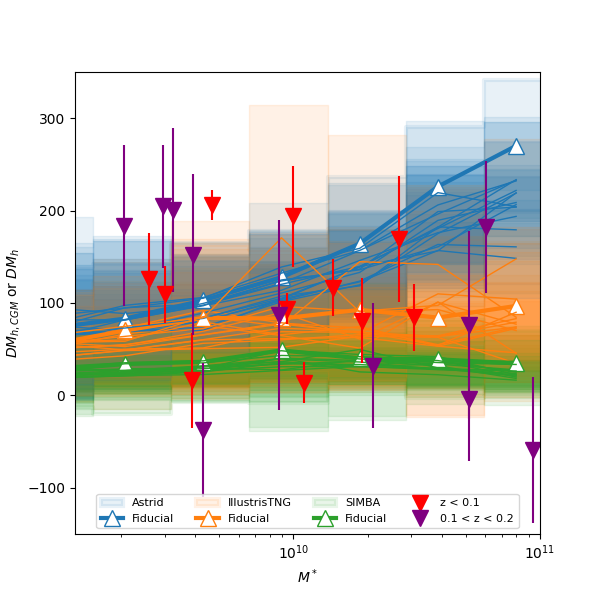

In [47]:
import importlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import camels_tools
import stack_tools
from camels_tools import analyze_halos,load_snapshot,plot_theory_predictions
from camels_tools import from_file
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import os
import pandas as pd
import dmh_tools
%matplotlib ipympl
from glob import glob
ROOT_PATH = os.getcwd() + '/../'

# Do the stacking, 
# Write to .h5

all_bminmax = [[0.10,0.20],[0.13,0.20],[0.10,0.16]]
M_star_cen = np.geomspace(1e9,8e10,num = 7)
all_snaps = ['090','088','086','084','082']
models = ['Astrid','IllustrisTNG','SIMBA']
plot_weightindex = 2
old_files = glob(os.path.join(ROOT_PATH,'data_products','camels_stack','*.h5'))
for f in old_files:
    print('Removing',f)
    os.remove(f)

for nnn in all_snaps:
    filepaths = glob(os.path.join(ROOT_PATH,'data_products','camels_data','20250414',f'*snap{nnn}_haloDM.csv'))
    for filepath in filepaths:    
        num_halos = 40
        M_200_min = 0
        M_200_max = np.inf
        sfr_min = 0.0
        sfr_max = 100.0
        sim_df = load_snapshot(filepath)
        #print('Input:',filepath)
        for b_min,b_max in all_bminmax:
            out_path = os.path.join(ROOT_PATH,'data_products','camels_stack',os.path.split(filepath)[-1][:-4] + f'_bminmax={b_min:.2f}_{b_max:.2f}.h5')
            results, stack = analyze_halos(
                filepath = filepath,
                df = sim_df,
                num_halos=10,
                b_min=b_min,
                b_max=b_max,
                M_200_min=M_200_min,
                M_200_max=M_200_max,
                M_star_range = M_star_cen,
                width_factor = 2.5,
                sfr_min=sfr_min,
                sfr_max=sfr_max,
                out_file=out_path
            )

# Data outputs
_df = pd.read_csv(os.path.join(ROOT_PATH,'data_products/remove_clusters_lowdm_edgeon.csv'))
_df.set_index('name',inplace=True)
keep = dmh_tools.not_clusters(_df) * dmh_tools.not_edge_on(_df) * dmh_tools.not_scattered(_df) * dmh_tools.not_elliptical(_df) * dmh_tools.not_low_dm(_df)
df = _df[keep]

plot_mstar = 10**dmh_tools.best_stellar_mass(df)
plot_dm = df['DM_host_restframe']
plot_dmerr = dmh_tools.sigma_tot(df)
# Plot theory outputs
plt.figure(figsize = mpl.figsize(journal = 'apj',fraction_of_textwidth = 1,height_per_width=1))

def append_fill_between(x,y1,y2,xa,**kwargs):
    y1 = np.concatenate((y1,np.atleast_1d(y1[-1])))
    y2 = np.concatenate((y2,np.atleast_1d(y2[-1])))
    x = np.concatenate((x,np.atleast_1d(xa)))
    plt.fill_between(x,y1,y2,**kwargs)
    
for snap_id in all_snaps:
    snap_z = camels_tools.CAMELS_REDSHIFTS[snap_id]
    for b_min,b_max in all_bminmax:
        for ii,model in enumerate(models):
            #res = camels_tools.plot_theory_predictions(f'/Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/Astrid_1P_3_0_snap{snap_id}_haloDM_b={bb:.2f}.h5',
            #                ax = plt.gca(),alpha = 0.2,facecolor = 'C0',label = 'Astrid')
            stack_path = f'/Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/{model}_1P_3_0_snap{snap_id}_haloDM' + f'_bminmax={b_min:.2f}_{b_max:.2f}.h5'

            res = camels_tools.from_file(stack_path)
            bin_cen = np.sqrt(res['M_star_bins'][:,0] * res['M_star_bins'][:,1])
            xa =res['M_star_bins'][-1,-1] # add endpoint of last bin for plotting only
            # if fiducial
            if b_min == 0.10 and b_max == 0.16 and snap_z == 0.1:
                append_fill_between(bin_cen,
                    res['weighted_mean'][plot_weightindex,:] -res['weighted_std'][plot_weightindex,:],
                    res['weighted_mean'][plot_weightindex,:] +res['weighted_std'][plot_weightindex,:],
                    xa = xa,
                    alpha = 0.1,
                    color = f'C{ii}', label = model,linewidth = 3,step = 'mid')
                plt.plot(bin_cen, res['weighted_mean'][plot_weightindex,:],color = f'C{ii}',linewidth = 3,marker = '^',markersize = 12,markerfacecolor='white',label = 'Fiducial')
            else:
                append_fill_between(bin_cen,
                    res['weighted_mean'][plot_weightindex,:] -res['weighted_std'][plot_weightindex,:],
                    res['weighted_mean'][plot_weightindex,:] +res['weighted_std'][plot_weightindex,:],
                    xa = xa,
                    alpha = 0.1,
                    color = f'C{ii}',step = 'mid')
                plt.plot(bin_cen, res['weighted_mean'][plot_weightindex,:],color = f'C{ii}',linewidth = 1)
            #res = camels_tools.plot_theory_predictions(stack_path,
            #                ax = plt.gca(),alpha = 0.2,facecolor = 'C1',label = 'IllustrisTNG')    

    

ci = df['primary_z_spec'] < 0.1
fo = (0.1 < df['primary_z_spec']) * (df['primary_z_spec'] < 0.2)
plt.errorbar(x = plot_mstar[ci],y = plot_dm[ci],yerr = plot_dmerr[ci], linestyle = 'none',marker = 'v',color = 'red',label = 'z < 0.1',markersize = 12)
plt.errorbar(x = plot_mstar[fo],y = plot_dm[fo],yerr = plot_dmerr[fo], linestyle = 'none',marker = 'v',color = 'purple',label = '0.1 < z < 0.2',markersize = 12)
plt.xscale('log')
plt.xlim(1.3e9,1e11)
plt.ylim(-150,350)
plt.xlabel(r'$M^*$')
ax1 = plt.gca()
ax1.set_ylabel(r'$DM_{h,CGM}$ or $DM_{h}$',color = 'black')
ax1.legend(loc = 'lower center',ncols = 4,fontsize = 8)

#ax2 = ax1.twinx()
#ax2.set_ylabel(r'$DM_{h}$',color = 'red')
#ax2.tick_params(axis='y', colors='red',left = False, right = True)
#ax2.set_ylim(-150,350)
snap_str = f'{b_min:.2f} < b < {b_max:.2f},z = {snap_z:.2f}'
#plt.title(r'Snapshot: ' + snap_str)
plt.savefig(f'/Users/calvinleung/kko_host_paper/figures/msdm.pdf',dpi = 110,bbox_inches='tight')
plt.savefig(f'/Users/calvinleung/kko_host_paper/figures/msdm.png',dpi = 110,bbox_inches='tight')
        #for ii, ms, dm in zip(np.arange(plot_mstar.size),plot_mstar,plot_dm):
        #    if dm < 150:



min of ll -28.957124604839862
min of ll -73.73420576459849


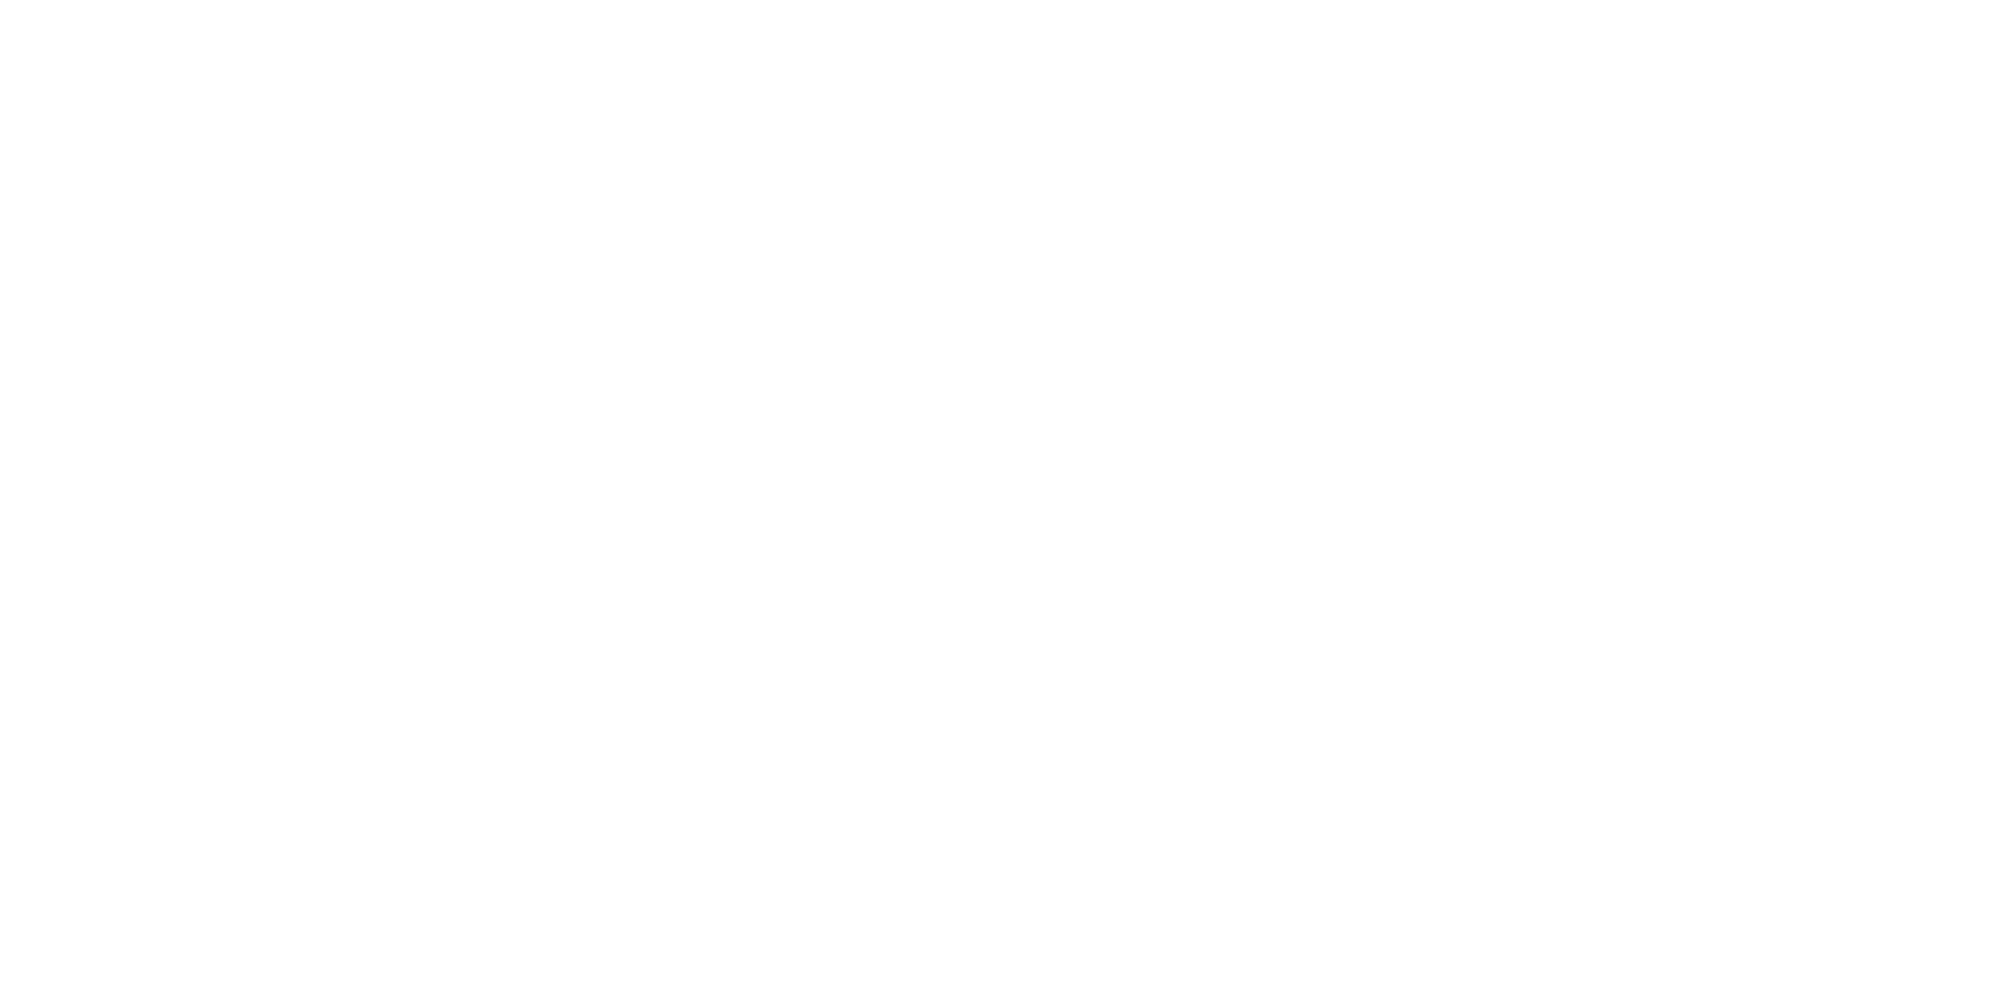

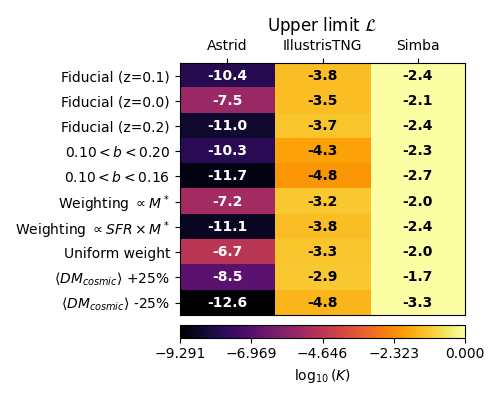

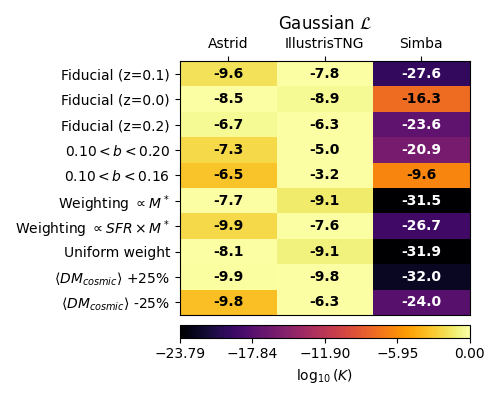

In [49]:
keep = dmh_tools.not_low_dm(df) * dmh_tools.not_scattered(df) * dmh_tools.not_clusters(df) * dmh_tools.not_edge_on(df) * dmh_tools.not_dwarf(df)
variants = [
    ['Fiducial (z=0.1)',('086',0.13,0.20,2)],
    ['Fiducial (z=0.0)',('090',0.13,0.20,2)],
    ['Fiducial (z=0.2)',('082',0.13,0.20,2)],
    [r'$0.10 < b < 0.20$',('086',0.1,0.2,2)],
    [r'$0.10 < b < 0.16$',('086',0.1,0.16,2)],
    [r'Weighting $\propto M^*$',('086',0.13,0.2,1)],
    [r'Weighting $\propto SFR \times M^*$',('086',0.13,0.2,3)],
    ['Uniform weight' ,('086',0.13,0.20,0)],
    [r'$\langle DM_{cosmic} \rangle$ +25%',('086',0.13,0.20,2,0.25)],
    [r'$\langle DM_{cosmic} \rangle$ -25%',('086',0.13,0.20,2,-0.25)]
]
plt.figure(figsize = (20,10))
log_likelihoods_per_burst_ul = np.zeros((3,len(variants),len(df)))
log_likelihoods_per_burst_exact = np.zeros((3,len(variants),len(df)))
# for iiz, snap_id in enumerate(['090','086','082']):
#     for iibb,bb in enumerate([0.13,0.16,0.20]):
#         for iiweight, weighting in enumerate(['Unweighted',r'$M^*$ weights','SFR weights',r'$M^*$ x SFR weights']):
#             variant_names[iiz,iibb,iiweight] = (f"{snap_id}; " + r"$b_{max}$" + f" = {bb:.2f}; {weighting}")
#             for iimodel, model in enumerate(['Astrid','IllustrisTNG','SIMBA']):
for iivariant,(variant_name,params) in enumerate(variants):
    for iimodel,model in enumerate(models):
        try:
            (snap_id, b_min, b_max, iiweight) = params
            corr = 0
        except ValueError:
            (snap_id, b_min, b_max, iiweight,corr) = params
        redshift_str = f"z = {camels_tools.CAMELS_REDSHIFTS[snap_id]:.2f}"
        snap_z = camels_tools.CAMELS_REDSHIFTS[snap_id]
        stack_path = f'/Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/{model}_1P_3_0_snap{snap_id}_haloDM' + f'_bminmax={b_min:.2f}_{b_max:.2f}.h5'
        results = from_file(stack_path)
        log_likelihoods_per_burst_ul[iimodel, iivariant] = stack_tools.log_likelihood(plot_mstar,
            plot_dm + corr * df['dm_igm'],
            plot_dmerr,
            results,
            verbose = False,
            mode = 'ul',
            weight_index = iiweight)
        log_likelihoods_per_burst_exact[iimodel, iivariant] = stack_tools.log_likelihood(plot_mstar,
            plot_dm + corr * df['dm_igm'],
            plot_dmerr,
            results,
            verbose = False,
            mode = 'exact', 
            weight_index=iiweight)



# UL likelihood
ll = np.sum(log_likelihoods_per_burst_ul[...,keep],axis = -1)
print('min of ll',np.min(ll))
log10ell = ll * np.log10(np.e)
fig = plt.figure(figsize = (5,4))
plt.title(r'Upper limit $\mathcal{L}$')
stack_tools.plot_fig2(fig,plt.gca(),log10ell, xnames = ['Astrid','IllustrisTNG','Simba'], 
    ynames = np.array([v[0] for v in variants]), cbar_label = r'$\log_{10}(K)$',
    out_file = os.path.join(ROOT_PATH,'figures/model_selection_ul.pdf'))
plt.tight_layout()

# Gaussian likelihood
ll = np.sum(log_likelihoods_per_burst_exact[...,keep],axis = -1)
print('min of ll',np.min(ll))
log10ell = ll * np.log10(np.e)
fig = plt.figure(figsize = (5,4))
plt.title(r'Gaussian $\mathcal{L}$')
stack_tools.plot_fig2(fig,plt.gca(),log10ell, xnames = ['Astrid','IllustrisTNG','Simba'], 
    ynames = np.array([v[0] for v in variants]), cbar_label = r'$\log_{10}(K)$',
    out_file = os.path.join(ROOT_PATH,'figures/model_selection_gauss.pdf'))
plt.tight_layout()